# NetworkSampler Tutorial

This notebook provides a step-by-step guide to using **NetworkSampler** for space-filling sampling on networks and semi-supervised node classification via label propagation.

For more details about the space-filling sampling algorithm, see the paper:

> del Gobbo E., Fontanella L., Ippoliti L., Di Zio S., Fontanella S., Cucco A. (2026). *A space-filling sampling approach for collective classification of social media data*. Advances in Data Analysis and Classification. [https://doi.org/10.1007/s11634-026-00670-z](https://doi.org/10.1007/s11634-026-00670-z)

For more details about the Python implementation and NetworkSampler package:

- **Website (including documentation):** https://edgresearch.github.io/pylib_networksampler
- **Source:** https://github.com/edgresearch/pylib_networksampler
- **Pip Package:** https://pypi.org/project/networksampler

## Installation

If you haven't installed NetworkSampler yet:

In [1]:
!pip install networksampler

## Package information

In [2]:
import networksampler
networksampler.info()

NetworkSampler v0.9.5
Space-filling sampling designs for graphs

Author:  Emiliano del Gobbo
Paper:   del Gobbo E., Fontanella L., Ippoliti L., Di Zio S., Fontanella S., Cucco A.
         https://doi.org/10.1007/s11634-026-00670-z
Source:  https://github.com/edgresearch/pylib_networksampler
License: LGPL-3.0

Python:     3.14.0
NumPy:      2.4.2
NetworkX:   3.6.1
Scipy:      1.17.0


## 1. Generating a test network

We use NetworkX to generate a network with two communities, simulating a scenario where nodes belong to different classes.

In [45]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the sizes of the two communities (500 nodes each for a total of 1000)
sizes = [500, 500]

# 2. Define the connection probabilities (SBM parameter matrix)
# - 0.05: probability of connection between nodes in the SAME community
# - 0.005: probability of connection between nodes in DIFFERENT communities
probs = [
    [0.08, 0.03],
    [0.03, 0.08]
]

# 3. Generate the network using the Stochastic Block Model
G_full = nx.stochastic_block_model(sizes, probs, seed=42)

# 4. Extract the Giant Component to ensure the graph is fully connected
largest_cc = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(largest_cc).copy()

# 5. Extract the adjacency matrix
A = nx.adjacency_matrix(G).todense()

print(f"Nodes: {A.shape[0]}")
print(f"Edges: {int(np.sum(A) / 2)}")

Nodes: 1000
Edges: 27534


Let's visualize the adjacency matrix to see the community structure:

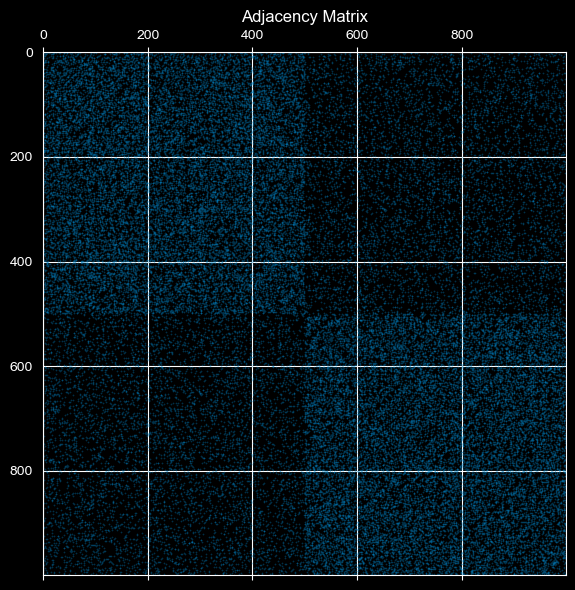

In [46]:
plt.figure(figsize=(6, 6))
plt.spy(A, markersize=0.1, color='#0284c7')
plt.title('Adjacency Matrix')
plt.tight_layout()
plt.show()

## 2. Computing the shortest path matrix

The space-filling algorithm operates on geodesic distances between nodes. Precompute this matrix once and reuse it across multiple sampling runs:

In [47]:
D = networksampler.compute_shortest_length_paths_matrix(A)

print(f"Matrix shape: {D.shape}")
print(f"Max distance: {D.max():.0f}")
print(f"Mean distance: {D.mean():.2f}")

Matrix shape: (1000, 1000)
Max distance: 3
Mean distance: 2.00


## 3. Space-filling sampling

The core function `sa_sampling` selects a set of seed nodes that are well spread across the network, minimizing the coverage criterion via simulated annealing.

**Parameters:**
- `p` and `q`: control the coverage criterion. Recommended: `p=-4`, `q=4`
- `r`: cooling rate for simulated annealing
- `D`: precomputed shortest path matrix (optional, avoids recomputing)
- `random_seed`: for reproducible results

In [48]:
# Sample 30 nodes (3% of 1000)
nodes_sf, cost = networksampler.sa_sampling(
    A, 30, p=-4, q=4, r=0.1, D=D, random_seed=42
)

print(f"Sampled nodes: {nodes_sf}")
print(f"Coverage cost: {cost:.4f}")

Sampled nodes: [ 15  20  28  58  75 120 133 169 174 278 310 388 398 408 421 456 557 574
 594 613 665 670 715 742 830 839 902 935 956 996]
Coverage cost: 4.1376


## 4. Comparing with other sampling strategies

NetworkSampler also provides centrality-based random sampling. Let's compare the space-filling design against common alternatives:

In [49]:
# Random sample proportional to degree centrality
nodes_degree = networksampler.node_random_sample(A, 30, measure="degree", random_seed=42)

# Random sample proportional to betweenness centrality
nodes_betw = networksampler.node_random_sample(A, 30, measure="betweenness", random_seed=42)

# Random sample proportional to closeness centrality
nodes_close = networksampler.node_random_sample(A, 30, measure="closeness", random_seed=42)

# Simple random sample (uniform)
rng = np.random.default_rng(42)
nodes_random = np.sort(rng.choice(A.shape[0], 30, replace=False))

print(f"Space-filling: {nodes_sf}")
print(f"Degree:        {np.sort(nodes_degree)}")
print(f"Betweenness:   {np.sort(nodes_betw)}")
print(f"Random:        {nodes_random}")

Space-filling: [ 15  20  28  58  75 120 133 169 174 278 310 388 398 408 421 456 557 574
 594 613 665 670 715 742 830 839 902 935 956 996]
Degree:        [ 44  65  95 128 154 193 226 354 370 436 441 448 465 554 631 643 682 696
 757 760 773 778 785 821 826 857 892 927 970 975]
Betweenness:   [ 45  67  95 128 154 191 224 355 370 435 440 447 463 554 631 642 682 696
 755 759 773 777 784 820 825 856 891 928 969 974]
Random:        [ 83  86  92 126 181 197 367 401 422 427 443 445 495 506 516 544 636 641
 682 706 723 748 752 775 777 821 830 837 921 958]


### Visualizing the sampled nodes on the network

Let's compare how different sampling strategies distribute the seeds across the network:

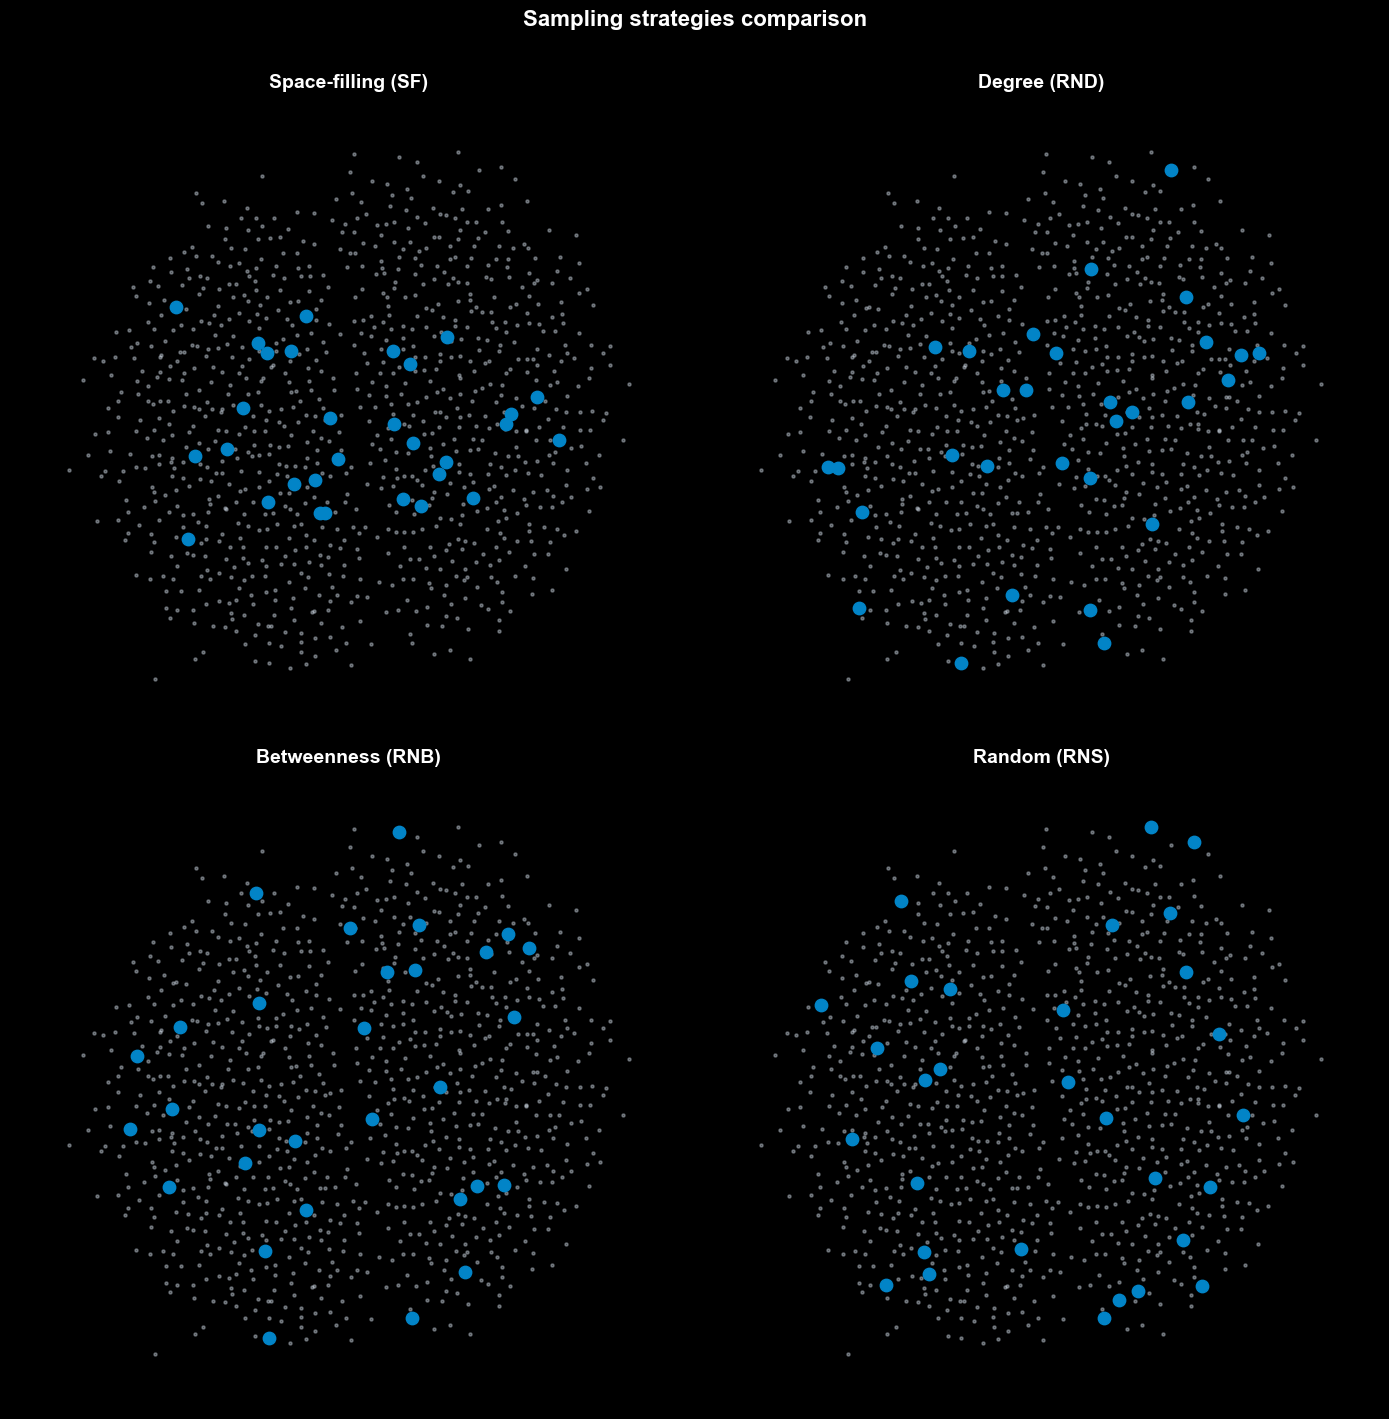

In [50]:
pos = nx.spring_layout(G, seed=42, k=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

samples = {
    'Space-filling (SF)': nodes_sf,
    'Degree (RND)': np.sort(nodes_degree),
    'Betweenness (RNB)': np.sort(nodes_betw),
    'Random (RNS)': nodes_random
}

for ax, (title, sampled) in zip(axes.flat, samples.items()):
    # Draw all nodes small and gray
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=5, node_color='#cbd5e1', alpha=0.4)
    # Draw sampled nodes larger and blue
    nx.draw_networkx_nodes(G, pos, nodelist=sampled, ax=ax, node_size=80, node_color='#0284c7')
    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.02, width=0.3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sampling strategies comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Two-phase sampling for large networks

For networks larger than 5000 nodes, the full shortest path matrix becomes expensive. The `sa_sampling_twophases` function uses a two-step approach:

1. First, a subgraph is sampled using centrality-based node selection
2. Then, the space-filling design is applied on the subgraph

In [51]:
nodes_2ph, cost_2ph = networksampler.sa_sampling_twophases(
    A, ns=10, p=-4, q=4, r=0.1,
    centrality_measure="betweenness",
    first_phase_sample_fraction=0.2
)

print(f"Sampled nodes: {nodes_2ph}")
print(f"Coverage cost: {cost_2ph:.4f}")

Sampled nodes: [ 44 105 246 289 315 434 507 544 696 720]
Coverage cost: 3.7106


## 6. Node centrality measures

The utility function `nodes_centrality_measures` computes multiple centrality metrics at once:

Top 5 nodes by betweenness: [709, 329, 665, 119, 839]


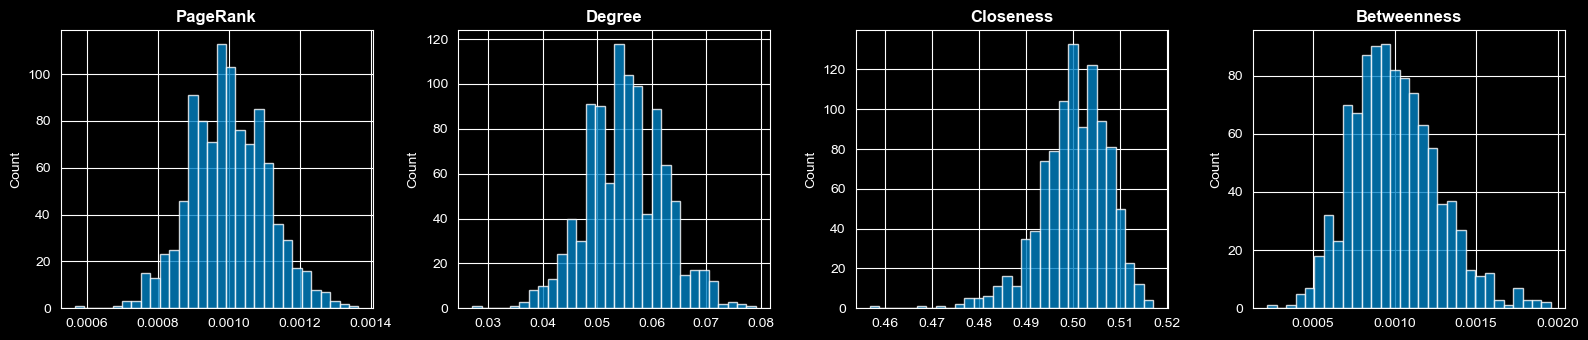

In [52]:
from networksampler.utils import nodes_centrality_measures

pagerank, degree, closeness, betweenness = nodes_centrality_measures(A)

# Top 5 nodes by betweenness centrality
top5 = sorted(betweenness, key=betweenness.get, reverse=True)[:5]
print(f"Top 5 nodes by betweenness: {top5}")

# Visualize centrality distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

metrics = {
    'PageRank': pagerank,
    'Degree': degree,
    'Closeness': closeness,
    'Betweenness': betweenness
}

for ax, (name, values) in zip(axes, metrics.items()):
    ax.hist(list(values.values()), bins=30, color='#0284c7', edgecolor='white', alpha=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 7. Complete example: label propagation

Here we combine NetworkSampler with label propagation and compare different sampling strategies.

In [23]:
# 1. Define the parameters for the Stochastic Block Model (SBM)
# Let's create a network with 2 distinct communities (e.g., two social groups)
# of 500 nodes each, totaling 1000 nodes.
sizes = [500, 500]

# Define the probability matrix of edge creation.
# - 0.05 (5%) probability for nodes within the same community to connect.
# - 0.005 (0.5%) probability for nodes in different communities to connect.
probs = [
    [0.05, 0.005],
    [0.005, 0.05]
]

# Generate the graph using the Stochastic Block Model
G_full = nx.stochastic_block_model(sizes, probs, seed=42)

# 2. Extract the Largest Connected Component
# Always a good practice to avoid disconnected nodes that cause infinite distances
largest_cc = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(largest_cc).copy()

# Extract the dense adjacency matrix
A = nx.adjacency_matrix(G).todense()

# 3. Assign ground truth labels based on the block membership
# NetworkX automatically assigns the 'block' attribute (0 or 1 in this case)
labels = np.zeros(G.number_of_nodes(), dtype=int)

# Re-map labels carefully since node IDs might not be contiguous
# after extracting the subgraph
node_list = list(G.nodes(data=True))
for i, (node, data) in enumerate(node_list):
    labels[i] = data['block']

print(f"Total nodes in the Giant Component: {G.number_of_nodes()}")
print(f"Class 0 (Community A): {np.sum(labels == 0)} nodes")
print(f"Class 1 (Community B): {np.sum(labels == 1)} nodes")

Total nodes in the Giant Component: 1000
Class 0 (Community A): 500 nodes
Class 1 (Community B): 500 nodes


In [24]:
def label_propagation(A, labels, seeds):
    """Run label propagation and return accuracy on unlabeled nodes."""
    n = A.shape[0]
    W = np.array(A, dtype=float)
    D_diag = np.diag(W.sum(axis=1).A1 if hasattr(W.sum(axis=1), 'A1') else np.asarray(W.sum(axis=1)).flatten())
    L = D_diag - W

    u_mask = np.ones(n, dtype=bool)
    u_mask[seeds] = False
    u_idx = np.where(u_mask)[0]
    s_idx = seeds

    Luu = L[np.ix_(u_idx, u_idx)]
    Lus = L[np.ix_(u_idx, s_idx)]
    fs = labels[s_idx].astype(float)

    fu = np.linalg.solve(Luu, -Lus @ fs)
    predicted = (fu >= 0.5).astype(int)

    return np.mean(predicted == labels[u_idx])

In [25]:
# 3. Compare sampling strategies
n_seeds = 15

# Space-filling sampling
seeds_sf, _ = networksampler.sa_sampling(A, n_seeds, p=-4, q=4, r=0.1)

# Centrality-based sampling
seeds_degree = networksampler.node_random_sample(A, n_seeds, measure="degree")
seeds_betw = networksampler.node_random_sample(A, n_seeds, measure="betweenness")

# Uniform random sampling
rng = np.random.default_rng(42)
seeds_random = np.sort(rng.choice(500, n_seeds, replace=False))

# Evaluate
results = {
    'Space-filling': label_propagation(A, labels, seeds_sf),
    'Degree': label_propagation(A, labels, np.sort(seeds_degree)),
    'Betweenness': label_propagation(A, labels, np.sort(seeds_betw)),
    'Random': label_propagation(A, labels, seeds_random)
}

for method, acc in results.items():
    print(f"{method:15s} accuracy: {acc:.4f}")

Space-filling   accuracy: 0.8528
Degree          accuracy: 0.4995
Betweenness     accuracy: 0.4985
Random          accuracy: 0.4924


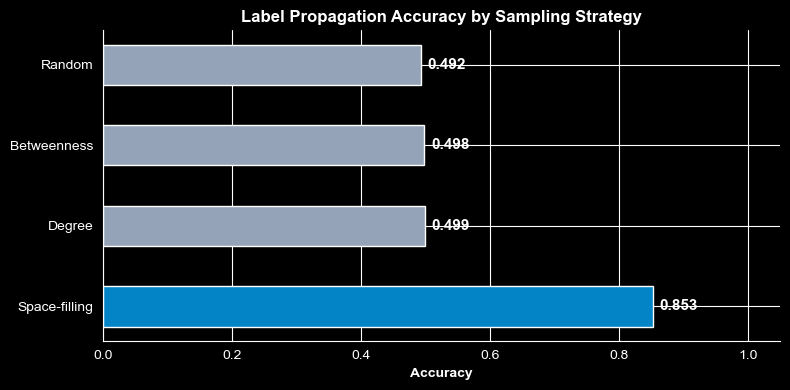

In [26]:
# Visualize results
fig, ax = plt.subplots(figsize=(8, 4))
methods = list(results.keys())
accuracies = list(results.values())
colors = ['#0284c7' if m == 'Space-filling' else '#94a3b8' for m in methods]

bars = ax.barh(methods, accuracies, color=colors, edgecolor='white', height=0.5)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy', fontweight='bold')
ax.set_title('Label Propagation Accuracy by Sampling Strategy', fontweight='bold')

for bar, acc in zip(bars, accuracies):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.3f}',
            va='center', fontweight='bold', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## References

del Gobbo E., Fontanella L., Ippoliti L., Di Zio S., Fontanella S., Cucco A. (2026). *A space-filling sampling approach for collective classification of social media data*. Advances in Data Analysis and Classification. [https://doi.org/10.1007/s11634-026-00670-z](https://doi.org/10.1007/s11634-026-00670-z)